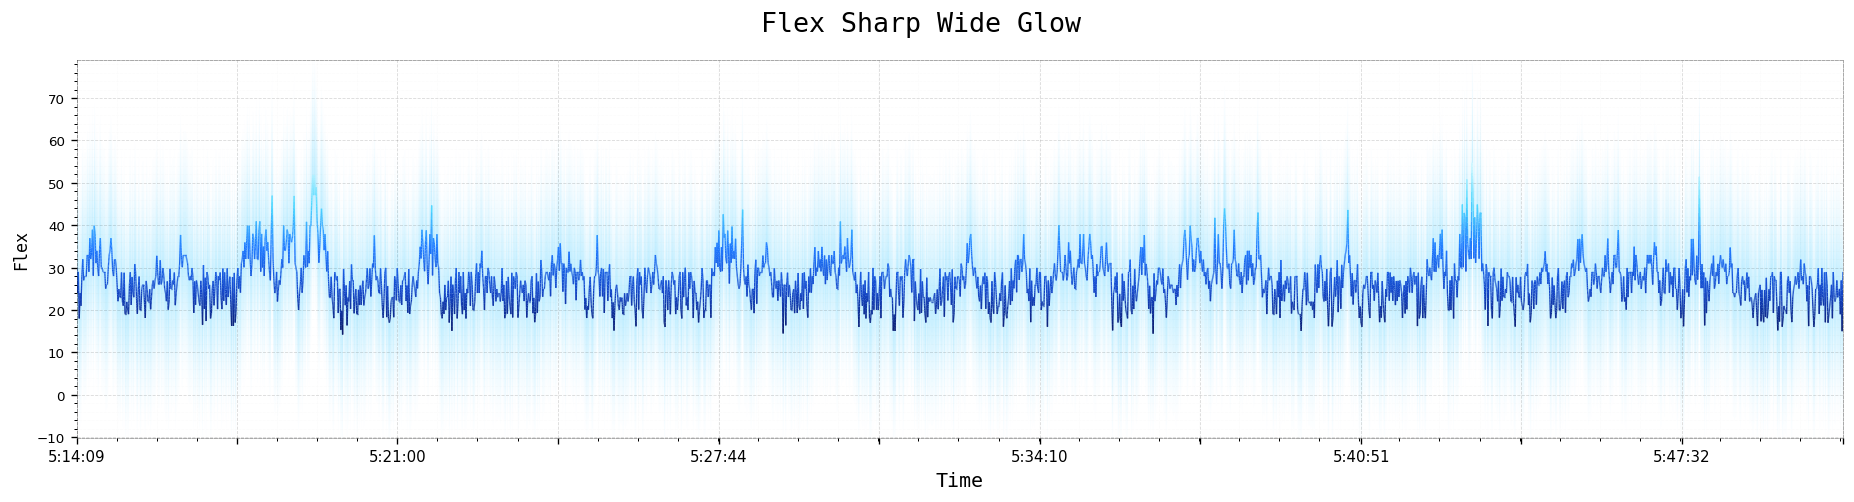

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection
from matplotlib.colors import LinearSegmentedColormap

def save_flex_sharp_wide_glow(
    csv_file_path,
    out_png_path="flex_dashboard_sharp_wide_glow.png",
    width_in=16,
    height_in=4.5,
    dpi=120
):
    # --- 1. Read data ---
    try:
        df = pd.read_csv(csv_file_path)
    except UnicodeDecodeError:
        df = pd.read_csv(csv_file_path, encoding="gbk")

    # --- 2. Clean data ---
    cols = {col.lower(): col for col in df.columns}
    flex_col = cols.get("flex")

    if not flex_col:
        raise ValueError("No 'flex' column found in the CSV file.")

    df[flex_col] = pd.to_numeric(df[flex_col], errors="coerce")
    df = df.dropna(subset=[flex_col])

    if "time" in df.columns:
        df["time_obj"] = pd.to_datetime(df["time"], format="%H:%M:%S", errors="coerce")
        df = df.dropna(subset=["time_obj"])
        time_labels = df["time"].astype(str).values
    else:
        time_labels = np.array([str(i) for i in range(len(df))])

    if len(df) < 2:
        raise ValueError("Not enough valid data points to draw the flex line.")

    x_raw = np.arange(len(df))
    y_data = df[flex_col].values

    # --- 3. Create transparent canvas ---
    fig, ax = plt.subplots(figsize=(width_in, height_in), dpi=dpi)
    fig.patch.set_alpha(0)
    ax.set_facecolor("none")

    # --- 4. Flex colormap: dark blue for low values, light blue for high values ---
    flex_colors = [
        "#0a1a6a",  # very dark blue
        "#1446c8",  # deep blue
        "#1f78ff",  # bright blue
        "#4fd8ff",  # cyan-blue
        "#d9fbff"   # very light blue
    ]
    cmap = LinearSegmentedColormap.from_list("flex_line", flex_colors, N=512)

    # --- 5. Interpolate for smoother line ---
    x_new = np.linspace(x_raw.min(), x_raw.max(), num=len(x_raw) * 10)
    y_new = np.interp(x_new, x_raw, y_data)

    # --- 6. Build gradient line segments ---
    points = np.array([x_new, y_new]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    y_min = float(np.min(y_new))
    y_max = float(np.max(y_new))
    if y_min == y_max:
        y_max = y_min + 1.0

    norm = plt.Normalize(y_min, y_max)

    # --- 7. Draw wide glow ---
    glow_color = cmap(0.72)
    y_range = y_max - y_min
    if y_range == 0:
        y_range = 1.0

    base_spread = y_range * 0.12
    layers = 20
    max_spread_factor = 6.0

    for i in range(layers):
        factor = max_spread_factor * (1 - i / layers)
        current_spread = base_spread * factor
        alpha = 0.01 + (0.03 * (i / layers))

        ax.fill_between(
            x_new,
            y_new - current_spread,
            y_new + current_spread,
            color=glow_color,
            alpha=alpha,
            edgecolor="none",
            linewidth=0
        )

    # --- 8. Draw main gradient line ---
    lc_main = LineCollection(
        segments,
        cmap=cmap,
        norm=norm,
        linewidths=0.8,
        alpha=1.0
    )
    lc_main.set_array(y_new)
    ax.add_collection(lc_main)

    # --- 9. Axis limits ---
    ax.set_xlim(x_raw.min(), x_raw.max())
    margin = y_range * 0.6
    ax.set_ylim(y_min - margin, y_max + margin)

    # --- 10. Grid and axes styling: black ---
    ax.minorticks_on()
    ax.grid(True, which="major", color="black", linestyle="--", linewidth=0.5, alpha=0.15)
    ax.grid(True, which="minor", color="black", linestyle=":", linewidth=0.3, alpha=0.05)

    for spine in ax.spines.values():
        spine.set_color("black")
        spine.set_alpha(0.4)
        spine.set_linestyle("--")
        spine.set_linewidth(0.5)

    ax.set_ylabel("Flex", color="black", fontsize=10, fontname="monospace")
    ax.tick_params(axis="y", colors="black", labelsize=8)

    # --- 11. X-axis labels ---
    num_grids = 12
    tick_indices = np.linspace(0, len(df) - 1, num_grids, dtype=int)
    ax.set_xticks(tick_indices)

    target_labels = 6
    show_every = max(num_grids // target_labels, 1)

    labels = []
    for i, idx in enumerate(tick_indices):
        labels.append(time_labels[idx] if (i % show_every == 0) else "")

    ax.set_xticklabels(labels, rotation=0, ha="center", fontsize=9, color="black")
    ax.set_xlabel("Time", color="black", fontsize=12, fontname="monospace")
    ax.tick_params(axis="x", colors="black")

    # --- 12. Title ---
    plt.suptitle(
        "Flex Sharp Wide Glow",
        color="black",
        fontsize=16,
        fontname="monospace",
        y=0.97
    )

    # --- 13. Save transparent PNG ---
    plt.subplots_adjust(left=0.06, right=0.98, top=0.88, bottom=0.18)
    plt.savefig(
        out_png_path,
        dpi=dpi,
        transparent=True,
        bbox_inches="tight",
        pad_inches=0.05
    )
    plt.show()

# --- Run ---
file_path = "data6_final.csv"
save_flex_sharp_wide_glow(file_path)